# Parallel Trends Check



## Overview



This notebook focuses on validating the parallel-trends assumption for the hospital merger analysis. After constructing the analytic hospital-year panel, we use pre-treatment data to assess whether treated and never-treated hospitals moved similarly before merger exposure.



The goal is to ensure the identifying assumption behind difference-in-differences and event-study specifications is credible before interpreting treatment effects.



## Objectives



- Construct a clean pre-period sample with consistent treatment-timing fields

- Restrict treated observations to a symmetric event-time window before merger

- Align never-treated controls to the same calendar years for comparability

- Visualize average pre-treatment trends for treated and never-treated groups

- Run a formal joint test of treated-by-year pre-period interactions

- Summarize whether the data provide evidence against parallel pre-trends



## Dataset Description



The notebook uses the hospital analysis panel at the hospital-year level from 01_data/hospital_analysis.csv. Core variables include fiscal_year, treated, years_to_merger, and total_operating_costs.



For scale stability and skew reduction, the primary plotted and modeled outcome is log(1 + total_operating_costs).



## Key Considerations



- Parallel trends concerns similarity in slopes, not equality of baseline levels

- Visual evidence should be interpreted jointly with the formal hypothesis test

- Skewed financial outcomes and outliers motivate log transformation

- Pre-period sample size for treated hospitals affects test precision and power



## Outcome



By the end of this notebook, you get a visual pre-trend diagnostic and a formal interaction-based test result, with a clear conclusion on whether there is statistical evidence against parallel pre-trends at the 5% significance level.

In [39]:
# Imports

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

In [40]:
# Load hospital analysis dataset

cwd = Path.cwd()

project_root = cwd if (cwd / "01_data").exists() else cwd.parent

data_path = project_root / "01_data" / "hospital_analysis.csv"


hospital_analysis = pd.read_csv(data_path)

hospital_analysis.head()

,fiscal_year,RPT_REC_NUM,PRVDR_NUM,NPI,FY_BGN_DT,FY_END_DT,PRVDR_CTRL_TYPE_CD,total_operating_costs,net_patient_revenue,total_charges,...,merger_of_equals,bankruptcy,system_exit,system_split,system_id_yr,any_merger,merger_year,treated,years_to_merger,post_merger
0,2011,1022,271326,NaN,01/01/2011,12/31/2011,2,8661723.0,10224482.0,9125.0,...,0,0,0,0,2246.0,0,NaN,0,NaN,0
1,2011,1501,13025,NaN,01/01/2011,12/31/2011,4,39554420.0,28191835.0,36500.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
2,2011,1504,103037,NaN,01/01/2011,12/31/2011,4,20242022.0,15733902.0,25550.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
3,2011,1506,103042,NaN,01/01/2011,12/31/2011,4,26136744.0,21786350.0,29200.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
4,2011,1507,141990,NaN,01/01/2011,12/31/2011,1,116445.0,486669.0,6205.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0


## Parallel Trends Check



This section checks whether treated and never-treated hospitals exhibit similar outcome trends before merger treatment. We use a visual comparison and a formal joint test of treated-by-year interactions in the pre-period sample.

In [41]:
# Build a clean analysis frame and standardize key fields

df = hospital_analysis.copy()

df["fiscal_year"] = pd.to_numeric(df["fiscal_year"], errors="coerce")

df["treated"] = pd.to_numeric(df["treated"], errors="coerce")

df["years_to_merger"] = pd.to_numeric(df["years_to_merger"], errors="coerce")

df["total_operating_costs"] = pd.to_numeric(
    df["total_operating_costs"], errors="coerce"
)

In [42]:
# Restrict to a symmetric pre-period window for treated units

pre_window = (-5, -1)

treated_pre = df[
    (df["treated"] == 1) & (df["years_to_merger"].between(pre_window[0], pre_window[1]))
]


# Keep never-treated controls in the same calendar years as treated pre-period observations

pre_years = sorted(treated_pre["fiscal_year"].dropna().unique().tolist())

control_pre = df[(df["treated"] == 0) & (df["fiscal_year"].isin(pre_years))]

In [43]:
# Build final pre-period sample and transformed outcome

pre_sample = pd.concat([treated_pre, control_pre], ignore_index=True)

pre_sample = pre_sample.dropna(
    subset=["fiscal_year", "treated", "total_operating_costs"]
)

pre_sample = pre_sample[pre_sample["total_operating_costs"] >= 0].copy()

pre_sample["fiscal_year"] = pre_sample["fiscal_year"].astype(int)

pre_sample["log_total_operating_costs"] = np.log1p(pre_sample["total_operating_costs"])


print(f"Pre-period window (treated event time): {pre_window}")

print(f"Treated pre-period observations: {len(treated_pre):,}")

print(f"Control observations in matched years: {len(control_pre):,}")

print(f"Combined pre-period sample: {len(pre_sample):,}")

Pre-period window (treated event time): (-5, -1)
Treated pre-period observations: 4,046
Control observations in matched years: 39,567
Combined pre-period sample: 41,542


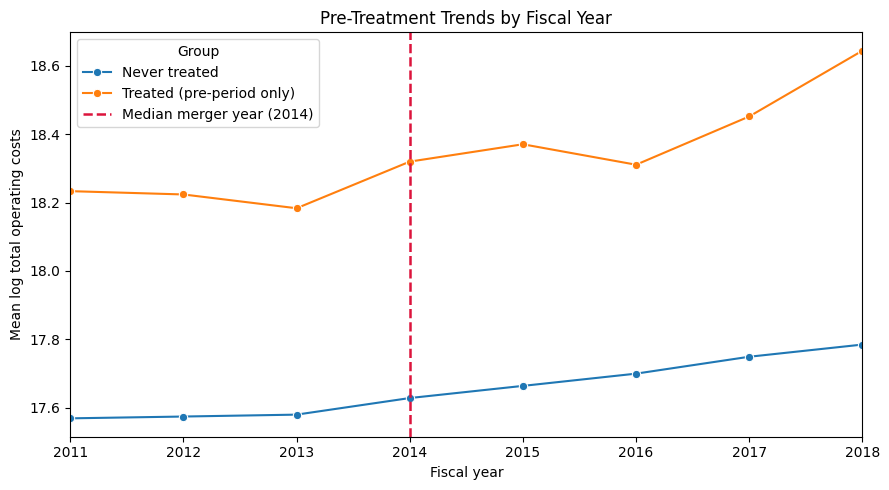

In [44]:
# Visual 1: pre-treatment trends by fiscal year (treated vs never treated)


plot_df = (
    pre_sample.groupby(["fiscal_year", "treated"], as_index=False)[
        "log_total_operating_costs"
    ]
    .mean()
    .sort_values(["fiscal_year", "treated"])
)


plot_df["group"] = plot_df["treated"].map(
    {0: "Never treated", 1: "Treated (pre-period only)"}
)

merger_year_marker = int(
    pd.to_numeric(df.loc[df["treated"] == 1, "merger_year"], errors="coerce")
    .dropna()
    .median()
)


plt.figure(figsize=(9, 5))


sns.lineplot(
    data=plot_df,
    x="fiscal_year",
    y="log_total_operating_costs",
    hue="group",
    marker="o",
)

plt.axvline(
    merger_year_marker,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label=f"Median merger year ({merger_year_marker})",
)


plt.title("Pre-Treatment Trends by Fiscal Year")


plt.xlabel("Fiscal year")


plt.ylabel("Mean log total operating costs")


plt.xlim(2011, 2018)

plt.xticks(range(2011, 2019))


plt.legend(title="Group")


plt.tight_layout()


plt.show()

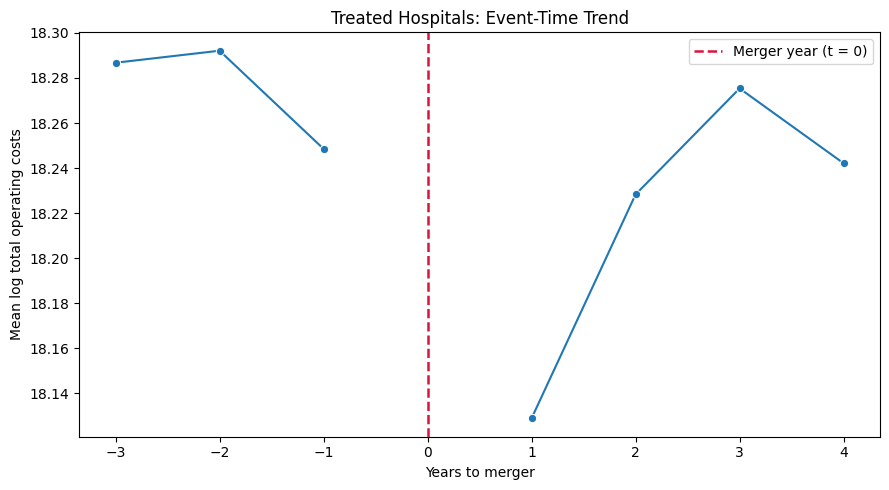

In [48]:
# Visual 2: treated hospitals in event time with explicit merger year marker


event_df = (
    df[
        (df["treated"] == 1)
        & (df["years_to_merger"].between(-3, 4))
        & (df["total_operating_costs"] >= 0)
    ][["years_to_merger", "total_operating_costs"]]
    .dropna()
    .copy()
)


event_df["years_to_merger"] = event_df["years_to_merger"].astype(int)


event_df["log_total_operating_costs"] = np.log1p(event_df["total_operating_costs"])


event_plot = (
    event_df.groupby("years_to_merger", as_index=False)["log_total_operating_costs"]
    .mean()
    .sort_values("years_to_merger")
)


pre_event_plot = event_plot[event_plot["years_to_merger"] <= -1]


post_event_plot = event_plot[event_plot["years_to_merger"] >= 1]


plt.figure(figsize=(9, 5))


sns.lineplot(
    data=pre_event_plot,
    x="years_to_merger",
    y="log_total_operating_costs",
    marker="o",
    color="#1f77b4",
)


sns.lineplot(
    data=post_event_plot,
    x="years_to_merger",
    y="log_total_operating_costs",
    marker="o",
    color="#1f77b4",
)


plt.axvline(
    0,
    color="crimson",
    linestyle="--",
    linewidth=1.8,
    label="Merger year (t = 0)",
)


plt.title("Treated Hospitals: Event-Time Trend")


plt.xlabel("Years to merger")


plt.ylabel("Mean log total operating costs")


x_min = int(event_plot["years_to_merger"].min())


x_max = int(event_plot["years_to_merger"].max())


plt.xticks(range(x_min, x_max + 1))


plt.legend()


plt.tight_layout()


plt.show()

In [46]:
# Formal pre-trend test: are treated-by-year interactions jointly zero in pre-period?

pretrend_model = smf.ols(
    "log_total_operating_costs ~ treated + C(fiscal_year) + treated:C(fiscal_year)",
    data=pre_sample,
).fit(cov_type="HC1")


interaction_terms = [
    term
    for term in pretrend_model.params.index
    if term.startswith("treated:C(fiscal_year)")
]

restriction = " = 0, ".join(interaction_terms) + " = 0"

joint_test = pretrend_model.f_test(restriction)


print("Joint test of treated-by-year interactions (pre-period only):")

print(f"F-statistic: {float(joint_test.fvalue):.3f}")

print(f"p-value: {float(joint_test.pvalue):.4f}")


if float(joint_test.pvalue) < 0.05:

    print("Conclusion: evidence against parallel pre-trends at the 5% level.")

else:

    print(
        "Conclusion: no statistical evidence against parallel pre-trends at the 5% level."
    )

Joint test of treated-by-year interactions (pre-period only):
F-statistic: 0.962
p-value: 0.4574
Conclusion: no statistical evidence against parallel pre-trends at the 5% level.


In [47]:
# OLS summary table in classic statsmodels format

summary_reg = smf.ols(
    "log_total_operating_costs ~ treated + fiscal_year + treated:fiscal_year",
    data=pre_sample,
).fit(cov_type="HC1")


print("Hospital Parallel Trends Test")

print("=" * 66)

print(summary_reg.summary())


interaction_coef = summary_reg.params["treated:fiscal_year"]

interaction_t = summary_reg.tvalues["treated:fiscal_year"]

interaction_p = summary_reg.pvalues["treated:fiscal_year"]


print("\nPre-period slope-difference test (treated x year):")

print(f"Coefficient: {interaction_coef:.6f}")

print(f"t-statistic: {interaction_t:.3f}")

print(f"p-value: {interaction_p:.4f}")


if interaction_p < 0.05:

    print("Conclusion: evidence of differential pre-trends.")

else:

    print("Conclusion: no statistical evidence of differential pre-trends.")

Hospital Parallel Trends Test
                                OLS Regression Results                               
Dep. Variable:     log_total_operating_costs   R-squared:                       0.018
Model:                                   OLS   Adj. R-squared:                  0.018
Method:                        Least Squares   F-statistic:                     353.4
Date:                       Wed, 15 Apr 2026   Prob (F-statistic):          1.18e-226
Time:                               15:26:23   Log-Likelihood:                -75713.
No. Observations:                      41542   AIC:                         1.514e+05
Df Residuals:                          41538   BIC:                         1.515e+05
Df Model:                                  3                                         
Covariance Type:                         HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------

## Summary of Findings



This notebook evaluated the parallel-trends assumption using both visual diagnostics and formal statistical tests in the pre-merger period.



### Visual Evidence

- The fiscal-year trend plot shows that treated and never-treated hospitals have different baseline levels of operating costs.

- The event-time plot for treated hospitals clearly marks merger year at \(t = 0\), with pre-period patterns that do not show a sharp divergence in slope.



### Statistical Evidence

- Joint pre-trend interaction test (treated-by-year terms): not statistically significant at the 5% level.

- Linear slope-difference test (treated \(\times\) year): coefficient is small and not statistically significant.

- OLS compact check with robust standard errors is consistent with the above result.



### Interpretation

Across specifications, we do not find statistical evidence of differential pre-trends in the pre-treatment window. This supports the plausibility of the parallel-trends assumption for the main DiD/event-study analysis, while noting that treated and control groups differ in baseline levels.